In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0


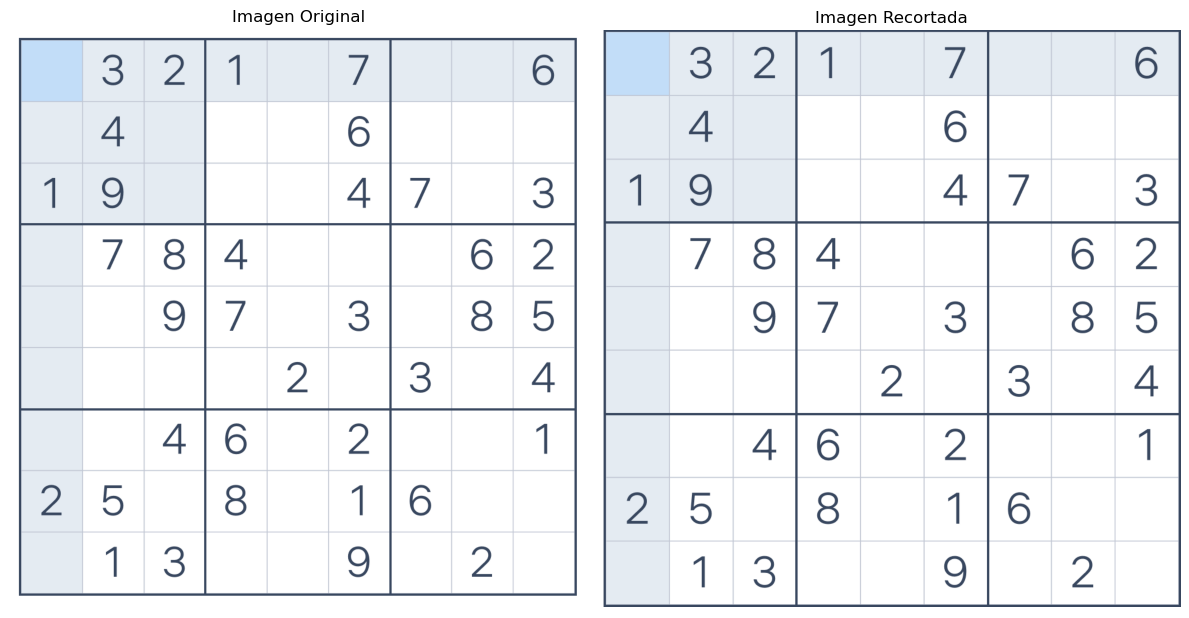

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'sudo.png'
image = cv2.imread(image_path)

gris = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#convertir imagen blanco y negro
_, binary = cv2.threshold(gris, 200, 255, cv2.THRESH_BINARY_INV)

bordes = cv2.Canny(binary, 100, 200)

#Encontrar contornos en la imagen
contorno_ex, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


contorno_ex = sorted(contorno_ex, key=cv2.contourArea, reverse=True)

x, y, w, h = cv2.boundingRect(contorno_ex[0]) 

#recortar la imagen usando rectángulo
cimage = image[y:y+h, x:x+w]

output_path = 'sudo_sin_bordes.jpg' 
cv2.imwrite(output_path, cimage)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(cimage, cv2.COLOR_BGR2RGB))
plt.title('Imagen Recortada')
plt.axis('off')

plt.tight_layout()
plt.show()

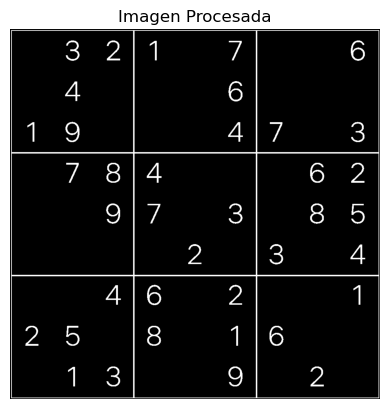

In [ ]:
import cv2
import matplotlib.pyplot as plt

sudoku_image = cv2.imread('sudo_sin_bordes.jpg', cv2.IMREAD_GRAYSCALE)

#filtro para reducir el ruido
sudoku_image = cv2.GaussianBlur(sudoku_image, (1, 1), 0)

#imagen binaria
_, sudoku_image = cv2.threshold(sudoku_image, 127, 255, cv2.THRESH_BINARY_INV)

#Detectar bordes y eliminar el borde exterior
contours, _ = cv2.findContours(sudoku_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(sudoku_image, contours, -1, (0, 0, 0), 2)


output_path = 'sudo_procesado.jpg'
cv2.imwrite(output_path, sudoku_image)


plt.imshow(sudoku_image, cmap='gray')
plt.title('Imagen Procesada')
plt.axis('off')
plt.show()



In [ ]:
import cv2
import os


sudoku_image = cv2.imread('sudo_procesado.jpg', cv2.IMREAD_GRAYSCALE)


alto, ancho = sudoku_image.shape
tamano_celda = ancho // 9 


output_folder = 'cuadros_sudoku'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

ajuste_superior = 10   
ajuste_inferior = 10    
ajuste_izquierdo = 10   
ajuste_derecho = 10     

contador = 1
for i in range(9):
    for j in range(9):
        x_inicio = j * tamano_celda + ajuste_superior
        y_inicio = i * tamano_celda + ajuste_inferior
        x_fin = (j + 1) * tamano_celda - ajuste_izquierdo
        y_fin = (i + 1) * tamano_celda - ajuste_derecho
        

        cuadro = sudoku_image[y_inicio:y_fin, x_inicio:x_fin]
        
        output_path = os.path.join(output_folder, f'cuadro_{contador}.jpg')
        cv2.imwrite(output_path, cuadro)
        contador += 1

print(f'81 cuadros guardados {output_folder}')


81 cuadros han sido guardados en la carpeta cuadros_sudoku


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np


(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0

# Expande las dimensiones de las imágenes para que tengan la forma (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)


datagen = ImageDataGenerator(
    rotation_range=15,   
    width_shift_range=0.1,  
    height_shift_range=0.1, 
    shear_range=0.1,      
    zoom_range=0.2,       
    horizontal_flip=True, 
    fill_mode='nearest'   
)

# Crear el modelo
model = models.Sequential([
    layers.Conv2D(128, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dropout(0.5),  
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


model.fit(datagen.flow(x_train, y_train, batch_size=100), 
          epochs=10,
          validation_data=(x_test, y_test))

#evalua modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Precisión del modelo: {test_acc:.4f}")

model.save('modelo.h5')


Epoch 1/10
600/600 [==============================] - 47s 77ms/step - loss: 0.6896 - accuracy: 0.7655 - val_loss: 0.1155 - val_accuracy: 0.9639
Epoch 2/10
600/600 [==============================] - 51s 85ms/step - loss: 0.2598 - accuracy: 0.9185 - val_loss: 0.0636 - val_accuracy: 0.9785
Epoch 3/10
600/600 [==============================] - 48s 80ms/step - loss: 0.1931 - accuracy: 0.9395 - val_loss: 0.0560 - val_accuracy: 0.9815
Epoch 4/10
600/600 [==============================] - 49s 82ms/step - loss: 0.1571 - accuracy: 0.9508 - val_loss: 0.0411 - val_accuracy: 0.9860
Epoch 5/10
600/600 [==============================] - 49s 81ms/step - loss: 0.1421 - accuracy: 0.9563 - val_loss: 0.0364 - val_accuracy: 0.9882
Epoch 6/10
600/600 [==============================] - 50s 84ms/step - loss: 0.1264 - accuracy: 0.9603 - val_loss: 0.0426 - val_accuracy: 0.9851
Epoch 7/10
600/600 [==============================] - 51s 85ms/step - loss: 0.1178 - accuracy: 0.9632 - val_loss: 0.0368 - val_accuracy:

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import os


model = tf.keras.models.load_model('modelo.h5')


def preprocess_cell(image):
    image = cv2.resize(image, (28, 28))
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=-1)  
    image = np.expand_dims(image, axis=0)   
    return image

#ver si una celda es completamente negra (vacía)
def is_empty_cell(image, threshold=10):
    avg_pixel_value = np.mean(image)
    return avg_pixel_value < threshold


def recognize_sudoku(cells_images):
    sudoku_grid = np.zeros((9, 9), dtype=int) 

    for idx, cell_image_path in enumerate(cells_images):
        cell_image = cv2.imread(cell_image_path, cv2.IMREAD_GRAYSCALE)

        if is_empty_cell(cell_image):
            row = idx // 9  
            col = idx % 9   
            sudoku_grid[row][col] = 0  
        else:
            cell_image = preprocess_cell(cell_image)
            
            prediction = model.predict(cell_image)
            digit = np.argmax(prediction)
            
            #asignar el número a la posición correcta 
            row = idx // 9 
            col = idx % 9   
            
            if digit != 0:#Si el número es 0 es espacio vacío
                sudoku_grid[row][col] = digit
    
    return sudoku_grid


image_folder = 'cuadros_sudoku/'
cells_images = []


for i in range(81):
    cell_image_path = os.path.join(image_folder, f'cuadro_{i+1}.jpg') 
    if os.path.exists(cell_image_path):
        cells_images.append(cell_image_path)
    else:
        print(f"Advertencia: No se encuentra la imagen {cell_image_path}")


sudoku = recognize_sudoku(cells_images)

1/1 [==============================] - 0s 27ms/step


In [90]:
print("Sudoku Reconocido:")
print(sudoku)

Sudoku Reconocido:
[[0 3 2 1 0 7 0 0 5]
 [0 4 0 0 0 8 0 0 0]
 [7 9 0 0 0 4 7 0 3]
 [0 7 8 4 0 0 0 6 2]
 [0 0 9 7 0 3 0 8 5]
 [0 0 0 0 2 0 3 0 4]
 [0 0 4 6 0 2 0 0 1]
 [2 5 0 8 0 1 6 0 0]
 [0 1 3 0 0 9 0 2 0]]
